In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# We read the csv data
df = pd.read_csv("bank_data_cleaned.csv")

In [3]:
# Here we create a list of the columns (features) we want to use
# These variables are related to the customer's repayment behavior
features_repay = [
    "BALANCE",
    "PAYMENTS",
    "CASH_ADVANCE",
    "PRC_FULL_PAYMENT",
    "CREDIT_LIMIT",
    "MINIMUM_PAYMENTS"
    ]

X_repay= df[features_repay]
# Here we select these columns from our dataframe (df)
# and store them in a new variable called X_repay
# X is typically used as input (features) for a model or clustering

In [4]:
# Create a scaler object (StandardScaler)
# This will standardize the data (make all features have mean = 0 and std = 1)
scaler = StandardScaler()

# Fit the scaler to the data and transform it
# - fit: learns the mean and standard deviation from X_repay
# - transform: scales the data using those values
# The result is a scaled version of X_repay
X_repay_scaled = scaler.fit_transform(X_repay)

Decide which value works the best for k, based on Inertia, Silhouette scores and Silhouette diagram.

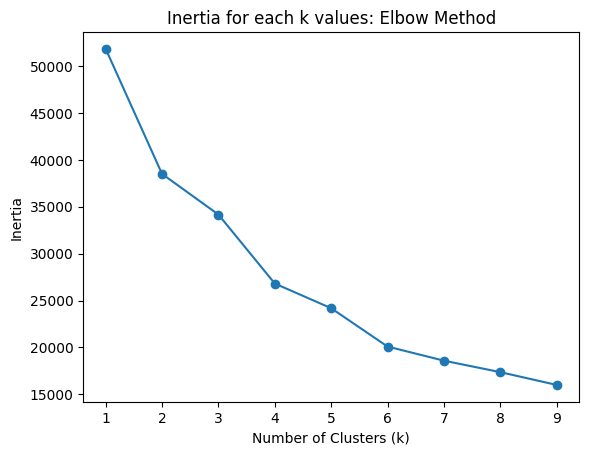

In [5]:
# Create an empty list to store inertia values for each k
inertia_repay = []
# Define a range of k values (number of clusters) from 1 to 9
k_inertia = range(1, 10)

# Loop through each k value 
for k in k_inertia:
    # Create a KMeans model with k clusters
    # random_state ensures we get the same result every time
    kmeans = KMeans(n_clusters=k, random_state=42)
    # Fit the model to the scaled data
    kmeans.fit(X_repay_scaled)
    # Store the inertia value (how compact the clusters are)
    inertia_repay.append(kmeans.inertia_)
 
 # Plot the results
plt.plot(k_inertia, inertia_repay, marker="o")
# Label the axes
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
# Title of the plot
plt.title("Inertia for each k values: Elbow Method")
plt.show()

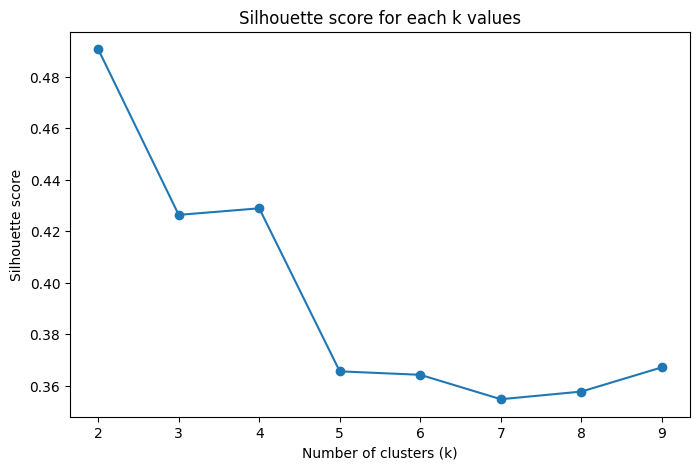

In [6]:
# Create an empty list to store silhouette scores for each k
silhouette_scores_repay = []
# Silhouette requires at least 2 clusters, so we start from 2
k_silhouette = range(2, 10)

# Loop through each k value
for k in k_silhouette:
    # Create a KMeans model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    # Fit the model and get cluster labels for each data point
    labels = kmeans.fit_predict(X_repay_scaled)
    # Calculate silhouette score for this clustering
    score = silhouette_score(X_repay_scaled, labels)
    # Store the score
    silhouette_scores_repay.append(score)

# Create the plot
plt.figure(figsize=(8, 5))
# Plot k vs silhouette score
plt.plot(k_silhouette, silhouette_scores_repay, marker="o")
# Label axes
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
# Title
plt.title("Silhouette score for each k values")
# Show plot
plt.show()

In [7]:
# Create and train a KMeans model with 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=42).fit(X_repay_scaled)
# Create and train a KMeans model with 4 clusters
kmeans_4 = KMeans(n_clusters=4, random_state=42).fit(X_repay_scaled)

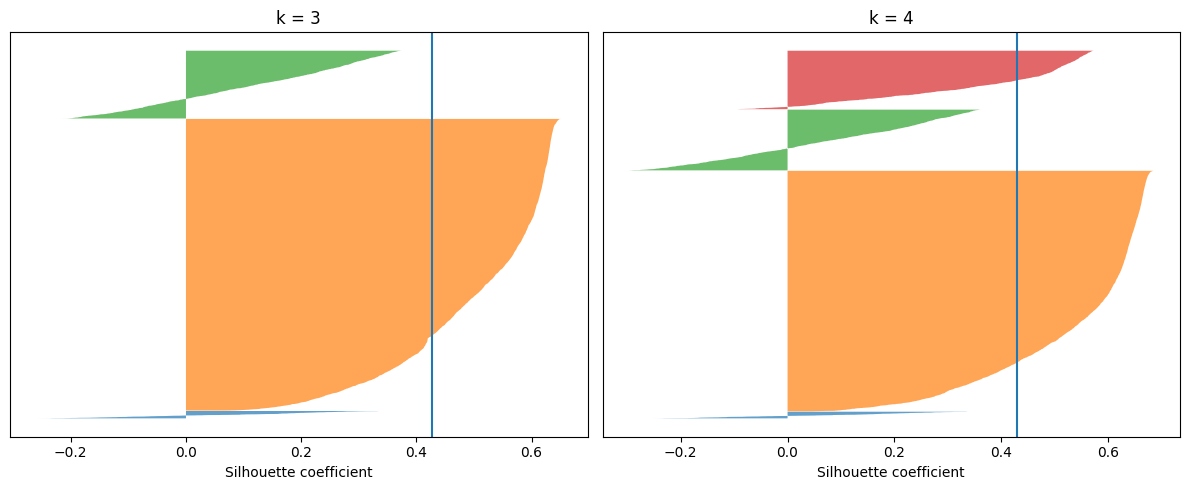

In [8]:
# Import the function that calculates silhouette values for each individual data point
from sklearn.metrics import silhouette_samples
# Import NumPy for working with arrays
import numpy as np
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns of plots
# This lets us compare the silhouette plot for k = 3 and k = 4 side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loop through each subplot axis together with each trained KMeans model
for ax, kmeans in zip(axes, [kmeans_3, kmeans_4]):
    # Get the cluster label for each data point
    labels = kmeans.labels_
    # Get the number of clusters used in the current model
    k = kmeans.n_clusters
    # Calculate the silhouette value for each data point
    silhouette_vals = silhouette_samples(X_repay_scaled, labels)
    # Calculate the average silhouette score for the whole clustering result
    avg_score = silhouette_score(X_repay_scaled, labels)
    # Starting point on the y axis for drawing the first cluster
    y_lower = 10
    
    # Loop through each cluster
    for i in range(k):
        # Select the silhouette values for the points that belong to cluster i
        vals = silhouette_vals[labels == i]
        # Sort the values so the shape looks cleaner in the plot
        vals.sort()
        # Define where this cluster section should end on the y axis
        y_upper = y_lower + len(vals)
        # Draw the silhouette shape for this cluster
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        # Move down on the y axis before drawing the next cluster
        y_lower = y_upper + 10

    # Draw a vertical line showing the average silhouette score
    ax.axvline(x=avg_score)
    
    # Add title showing the current k value
    ax.set_title(f"k = {k}")
    
    # Label the x axis
    ax.set_xlabel("Silhouette coefficient")
    
    # Remove y axis tick labels because they are not needed here
    ax.set_yticks([])
    
# Adjust spacing between the plots so everything fits nicely
plt.tight_layout()
# Show the final silhouette plots
plt.show()

When I tested k = 5, the silhouette diagram showed more negative values and cluster sizes became more imbalanced. So I decided to use 4 for K.

In [9]:
# Create a KMeans model with 4 clusters (based on earlier evaluation)
kmeans_repay = KMeans(n_clusters=4, random_state=42)

# Fit the model to the scaled data and assign each customer to a cluster
# The result (cluster labels: 0, 1, 2, 3) is saved as a new column in the dataframe
df["cluster_repay"] = kmeans_repay.fit_predict(X_repay_scaled)

# Count how many customers belong to each cluster
# sort_index() ensures clusters are shown in order (0, 1, 2, 3)
df["cluster_repay"].value_counts().sort_index()

cluster_repay
0     157
1    5668
2    1432
3    1379
Name: count, dtype: int64

In [10]:
# Group the data by cluster and calculate the average (mean) for each feature
# This shows the typical behavior of customers in each cluster
cluster_repay_summary = df.groupby("cluster_repay")[features_repay].mean().round(2)

# Print a label so it's clear what the output represents
print("Average values per cluster:")

# Display the summary table
cluster_repay_summary

Average values per cluster:


,BALANCE,PAYMENTS,CASH_ADVANCE,PRC_FULL_PAYMENT,CREDIT_LIMIT,MINIMUM_PAYMENTS
cluster_repay,,,,,,
0,5250.85,16686.85,8659.94,0.21,11650.00,2454.35
1,1007.15,1089.03,542.23,0.04,3149.53,539.72
2,4938.61,2848.60,2785.14,0.01,8699.13,2626.30
3,161.83,1841.26,119.22,0.78,5014.54,187.68


In [11]:
# Cluster 0 [Very active, heavy credits]
# Highest balance, highest payments, highest cash advance, low full payment, highest credit limit, high minimum payments

# Cluster 1 [Low activity, weak repayments]
# Low balance, lowest payments, low cash advance, very low full payment, lowest credit limit, low minimum payments

# Cluster 2 [High debt, weak repayments]
# Very high balance, not strong payments, high cash advance, lowest full payment, high credit limit, highest minimum payments

# Cluster 3 [Low debt, low risk]
# Lowest balance, relatively high payments, lowest cash advance, highest full payment, medium credit limit, lowest minimum payments

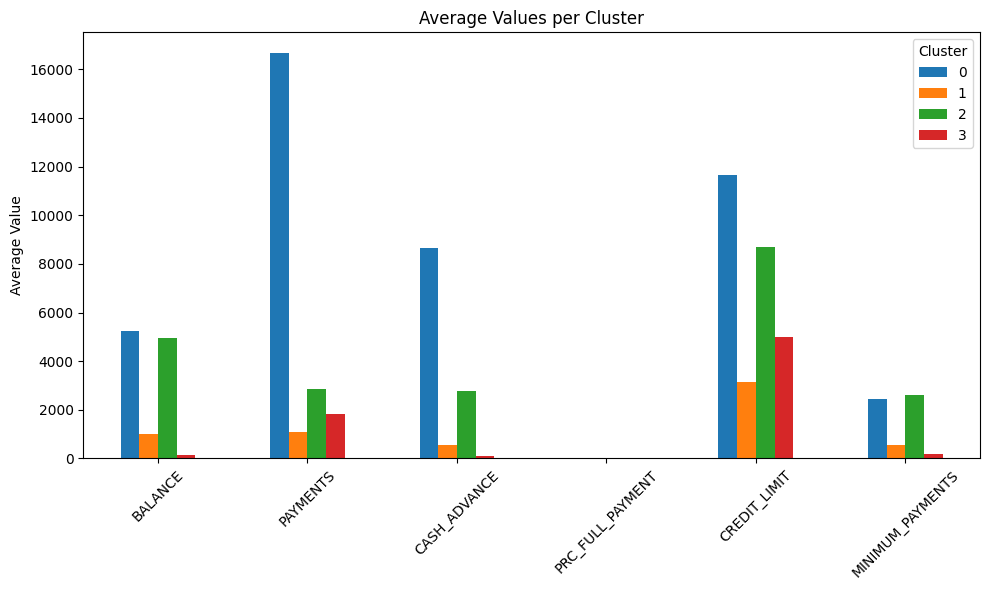

In [12]:
# Same as above but easier to compare clusters visually

# Transpose the summary table so features become the x axis (instead of clusters)
# This makes it easier to compare clusters for each feature
cluster_repay_summary.T.plot(kind="bar", figsize=(10, 6))

# Add a title to the plot
plt.title("Average Values per Cluster")
# Label the y axis
plt.ylabel("Average Value")
# Rotate x axis labels so they are easier to read
plt.xticks(rotation=45)
# Add a legend to show which color belongs to which cluster
plt.legend(title="Cluster")
# Adjust layout so everything fits nicely
plt.tight_layout()
# Display the plot
plt.show()

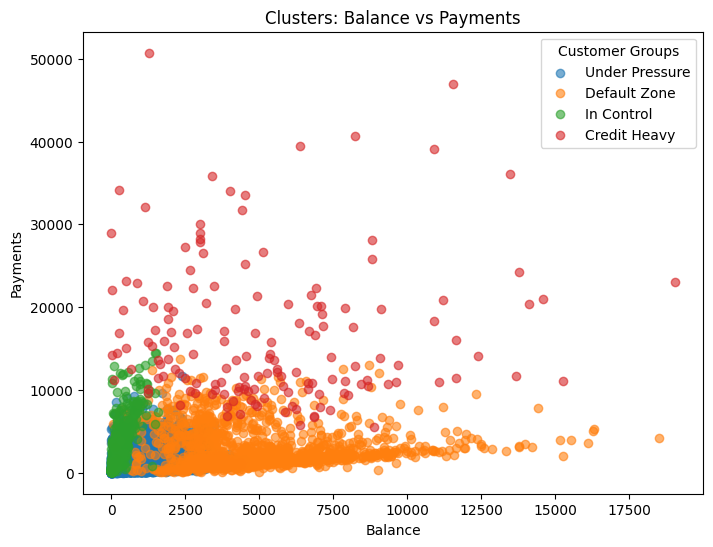

In [13]:
# Create a dictionary that maps cluster numbers to descriptive names
# This makes the clusters easier to understand instead of just using numbers
cluster_repay_names = {
    0: "Credit Heavy",
    1: "Under Pressure",
    2: "Default Zone",
    3: "In Control"
}

# Create a new column with the descriptive cluster names
# .map() replaces the numeric cluster labels with the names above
df["cluster_repay_name"] = df["cluster_repay"].map(cluster_repay_names)

# Create a new figure for the scatter plot
plt.figure(figsize=(8, 6))

# Loop through each unique cluster name
for name in df["cluster_repay_name"].unique():
    
    # Select only the customers that belong to this cluster
    subset = df[df["cluster_repay_name"] == name]
    
    # Plot BALANCE vs PAYMENTS for this cluster
    # Each cluster will appear in a different color
    plt.scatter(subset["BALANCE"], subset["PAYMENTS"], label=name, alpha=0.6)

# Label axes
plt.xlabel("Balance")
plt.ylabel("Payments")

# Add a title
plt.title("Clusters: Balance vs Payments")

# Add legend showing cluster names
plt.legend(title="Customer Groups")

# Show the plot
plt.show()

In [14]:
# Create a PCA model that reduces the data to 2 components (dimensions)
# This is usually done to make it possible to visualize high-dimensional data
pca_ability = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
# - fit: learns the main directions (patterns) in the data
# - transform: projects the data onto these 2 new components
# The result is a 2D version of the original dataset
X_pca_ability = pca_ability.fit_transform(X_repay_scaled)

In [15]:
# Show the principal components (how each original feature contributes)
pca_ability.components_

array([[ 0.54329469,  0.42075108,  0.46565434, -0.15980071,  0.44858341,
         0.29017599],
       [-0.22865563,  0.4408328 ,  0.05661659,  0.72526618,  0.29999072,
        -0.36629517]])

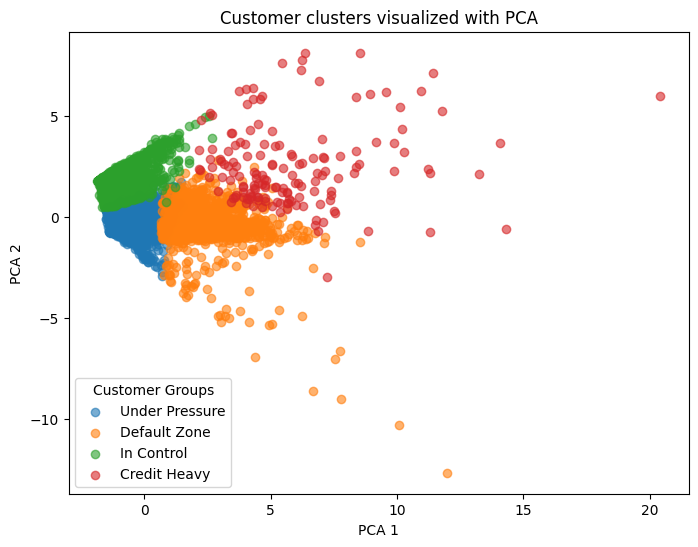

In [16]:
# Add the first principal component (PC1) to the dataframe
# This represents the most important pattern in the data
df["PCA1"] = X_pca_ability[:, 0]

# Add the second principal component (PC2) to the dataframe
# This represents the second most important pattern
df["PCA2"] = X_pca_ability[:, 1]

# Create a new figure for the plot
plt.figure(figsize=(8, 6))

# Loop through each cluster name
for name in df["cluster_repay_name"].unique():
    
    # Select only the customers belonging to this cluster
    subset = df[df["cluster_repay_name"] == name]
    
    # Plot PCA1 vs PCA2 for this cluster
    # Each cluster will have a different color
    plt.scatter(subset["PCA1"], subset["PCA2"], label=name, alpha=0.6)

# Label the axes
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Add a title
plt.title("Customer clusters visualized with PCA")

# Add legend showing cluster names
plt.legend(title="Customer Groups")

# Show the plot
plt.show()

In [17]:
# Define a list of features related to customer spending behavior
features_spender = [
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "BALANCE_FREQUENCY",                
    "PURCHASES",                        
    "BALANCE",                          
    "PAYMENTS"                          
]

# Select these columns from the dataframe to create the input data (X)
X_spender = df[features_spender]

# Scale the data using StandardScaler
# This ensures all features are on the same scale (mean = 0, std = 1)
X_spender_scaled = scaler.fit_transform(X_spender)

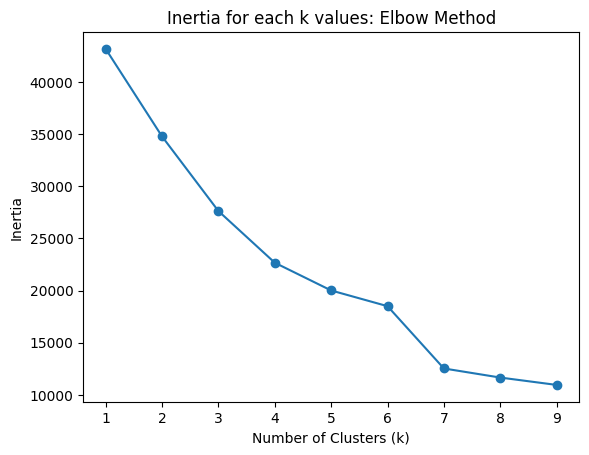

In [18]:
# Create an empty list to store inertia values for each k
inertia_spender = []

# Define a range of k values (number of clusters) from 1 to 9
k_inertia = range(1, 10)

# Loop through each k value
for k in k_inertia:
    
    # Create a KMeans model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Fit the model to the scaled spending data
    kmeans.fit(X_spender_scaled)
    
    # Store the inertia value (how compact the clusters are)
    inertia_spender.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(k_inertia, inertia_spender, marker="o")

# Label axes
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Add title
plt.title("Inertia for each k values: Elbow Method")

# Show plot
plt.show()

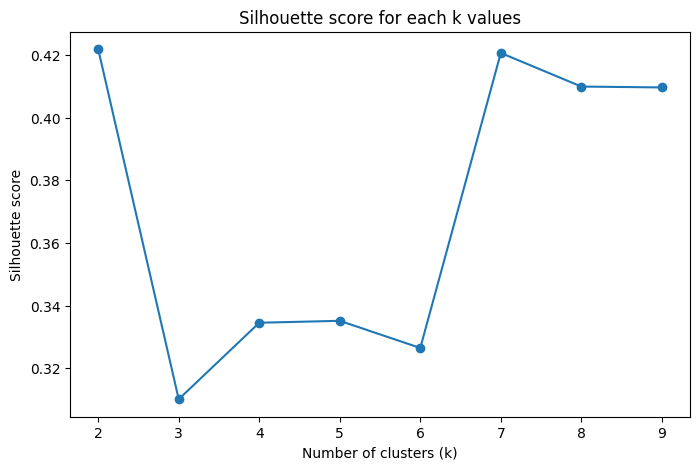

In [19]:
# Create an empty list to store silhouette scores for each k
silhouette_scores_spender = []

# Silhouette requires at least 2 clusters, so we start from 2
k_silhouette = range(2, 10)

# Loop through each k value
for k in k_silhouette:
    
    # Create a KMeans model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Fit the model and assign cluster labels to each data point
    labels = kmeans.fit_predict(X_spender_scaled)
    
    # Calculate the silhouette score for this clustering result
    score = silhouette_score(X_spender_scaled, labels)
    
    # Store the score
    silhouette_scores_spender.append(score)

# Create the plot
plt.figure(figsize=(8, 5))

# Plot k vs silhouette score
plt.plot(k_silhouette, silhouette_scores_spender, marker="o")

# Label axes
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")

# Add title
plt.title("Silhouette score for each k values")

# Show the plot
plt.show()

In [20]:
# Create and train a KMeans model with 6 clusters
kmeans_6 = KMeans(n_clusters=6, random_state=42).fit(X_spender_scaled)

# Create and train a KMeans model with 7 clusters
kmeans_7 = KMeans(n_clusters=7, random_state=42).fit(X_spender_scaled)

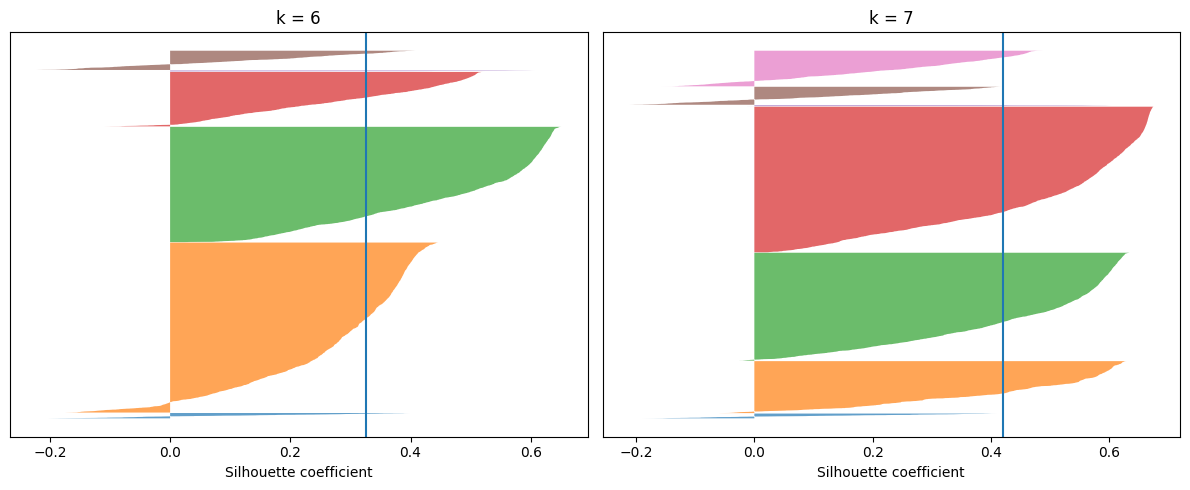

In [21]:
# Create a figure with 2 subplots (side by side)
# This allows us to compare k = 6 and k = 7 visually
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loop through each subplot and corresponding KMeans model
for ax, kmeans in zip(axes, [kmeans_6, kmeans_7]):
    
    # Get cluster labels for each data point
    labels = kmeans.labels_
    
    # Get number of clusters
    k = kmeans.n_clusters
    
    # Calculate silhouette value for each data point
    silhouette_vals = silhouette_samples(X_spender_scaled, labels)
    
    # Calculate average silhouette score for the model
    avg_score = silhouette_score(X_spender_scaled, labels)

    # Starting position on y-axis for plotting clusters
    y_lower = 10
    
    # Loop through each cluster
    for i in range(k):
        
        # Get silhouette values for points in cluster i
        vals = silhouette_vals[labels == i]
        
        # Sort values for cleaner visualization
        vals.sort()
        
        # Define upper boundary for this cluster on y-axis
        y_upper = y_lower + len(vals)

        # Plot the silhouette shape for this cluster
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        
        # Move down for the next cluster
        y_lower = y_upper + 10

    # Draw vertical line for average silhouette score
    ax.axvline(x=avg_score)
    
    # Set plot title to show current k
    ax.set_title(f"k = {k}")
    
    # Label x-axis
    ax.set_xlabel("Silhouette coefficient")
    
    # Remove y-axis ticks (not needed for interpretation)
    ax.set_yticks([])

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()

In [22]:
# Create a KMeans model with 7 clusters (chosen based on earlier evaluation)
kmeans_spender = KMeans(n_clusters=7, random_state=42)

# Fit the model to the scaled spending data and assign each customer to a cluster
# The cluster labels (0–6) are stored as a new column in the dataframe
df["cluster_spender"] = kmeans_spender.fit_predict(X_spender_scaled)

# Count how many customers belong to each cluster
# sort_index() ensures clusters are displayed in order (0 to 6)
df["cluster_spender"].value_counts().sort_index()

cluster_spender
0     114
1    1230
2    2554
3    3444
4      25
5     426
6     843
Name: count, dtype: int64

In [23]:
# Group the data by spending cluster and calculate the average (mean) for each feature
# This shows the typical spending behavior for each cluster
cluster_spender_summary = df.groupby("cluster_spender")[features_spender].mean().round(2)

# Print a label to clarify the output
print("Average values per cluster:")

# Display the summary table
cluster_spender_summary

Average values per cluster:


,PURCHASES_INSTALLMENTS_FREQUENCY,BALANCE_FREQUENCY,PURCHASES,BALANCE,PAYMENTS
cluster_spender,,,,,
0,0.26,0.85,1175.75,4803.49,15483.02
1,0.21,0.44,395.13,171.37,1093.12
2,0.83,0.97,1129.38,830.00,1199.60
3,0.07,0.97,412.71,1306.11,1131.14
4,0.71,0.95,27085.31,5351.55,27159.04
5,0.78,0.98,6033.92,2600.16,6087.82
6,0.24,0.99,809.25,6180.63,2454.72


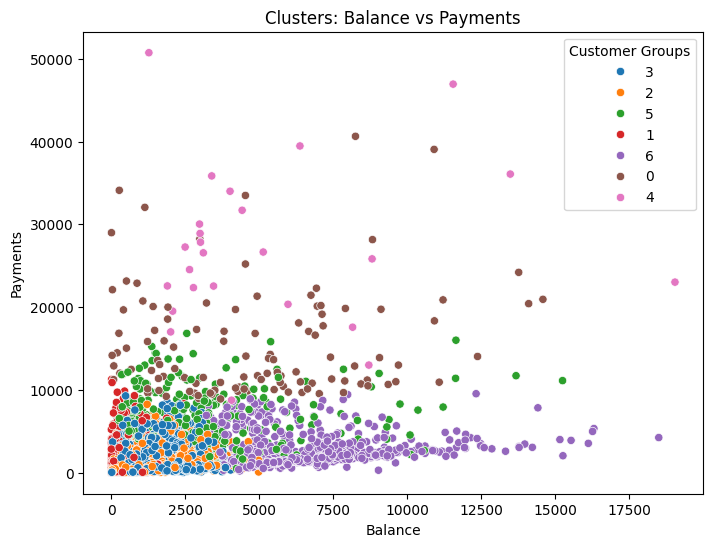

In [24]:
# Import seaborn for easier and cleaner visualizations
import seaborn as sns

# Create a dictionary to map cluster numbers to names (currently just numbers as strings)
cluster_spender_names = {
    0: "0", 1: "1", 2: "2", 3: "3",
    4: "4", 5: "5", 6: "6"
}

# Create a new column with cluster names instead of numeric labels
df["cluster_spender_name"] = df["cluster_spender"].map(cluster_spender_names)

# Create a figure
plt.figure(figsize=(8, 6))

# Create a scatter plot using seaborn
# - x = BALANCE
# - y = PAYMENTS
# - hue = cluster (color-coded groups)
sns.scatterplot(
    data=df,
    x="BALANCE",
    y="PAYMENTS",
    hue="cluster_spender_name"
)

# Label axes
plt.xlabel("Balance")
plt.ylabel("Payments")

# Add title
plt.title("Clusters: Balance vs Payments")

# Add legend showing cluster groups
plt.legend(title="Customer Groups")

# Show the plot
plt.show()

In [25]:
# Create a PCA model to reduce the data to 2 dimensions
# This makes it possible to visualize the data in a simple 2D plot
pca_spender = PCA(n_components=2)

# Fit the PCA model to the scaled data and transform it
# - fit: learns the main patterns (directions of variation) in the data
# - transform: converts the original data into 2 new variables (PCA1 and PCA2)
X_pca_spender = pca_spender.fit_transform(X_spender_scaled)

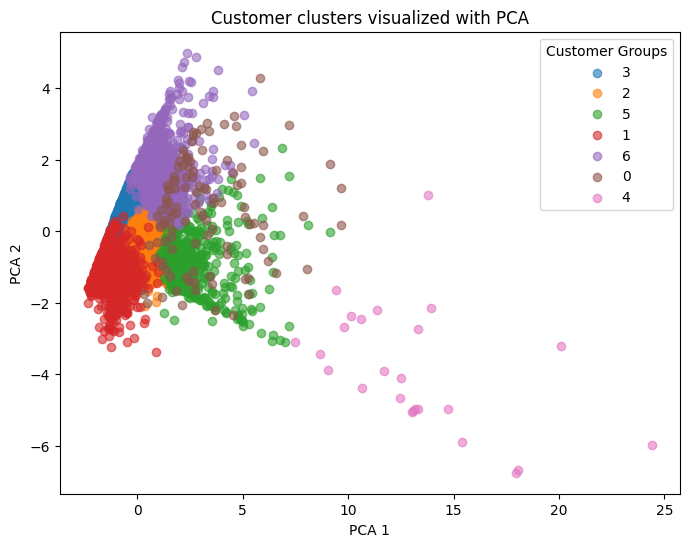

In [26]:
# Add the first principal component (PCA1) to the dataframe
# This represents the most important pattern in the spending data
df["PCA1"] = X_pca_spender[:, 0]

# Add the second principal component (PCA2) to the dataframe
# This represents the second most important pattern
df["PCA2"] = X_pca_spender[:, 1]

# Create a new figure
plt.figure(figsize=(8, 6))

# Loop through each cluster name
for name in df["cluster_spender_name"].unique():
    
    # Select only customers in this cluster
    subset = df[df["cluster_spender_name"] == name]
    
    # Plot PCA1 vs PCA2 for this cluster
    # Each cluster will appear in a different color
    plt.scatter(subset["PCA1"], subset["PCA2"], label=name, alpha=0.6)

# Label axes
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Add title
plt.title("Customer clusters visualized with PCA")

# Add legend showing cluster groups
plt.legend(title="Customer Groups")

# Show the plot
plt.show()

In [27]:
# Download the file to an excel file for further analysis 
df.to_excel("bank_clustered.xlsx", index=False)